In [4]:
pip install -U sumy

     |████████████████████████████████| 92kB 3.9MB/s 
     |████████████████████████████████| 10.1MB 6.7MB/s 
  Created wheel for pycountry: filename=pycountry-20.7.3-py2.py3-none-any.whl size=10746863 sha256=92db4847f55c306b040b2dcad7f5aed05a0b1047460ab484c59244f5629e4f30
  Stored in directory: /root/.cache/pip/wheels/33/4e/a6/be297e6b83567e537bed9df4a93f8590ec01c1acfbcd405348
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21680 sha256=07204c5dc72b15d215c243e3c070a75feee3e4fdbfad829876f4c71e62cfc37a
  Stored in directory: /root/.cache/pip/wheels/5a/4d/a1/510b12c5e65e0b2b3ce539b2af66da0fc57571e528924f4a52
Successfully built pycountry breadability


In [5]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize 
from sklearn.utils.extmath import randomized_svd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import networkx
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
import heapq


In [7]:
news = pd.read_csv('Dosyalar/news_summary_more.csv',sep=',', encoding='latin-1')

FileNotFoundError: ignored

In [ ]:
news.shape

(98401, 2)

In [ ]:
news.head()

,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


In [ ]:
news.isnull().sum()

headlines    0
text         0
dtype: int64

In [ ]:
news = news.dropna()
#news = news.drop(['Id','ProductId','UserId','ProfileName','HelpfulnessNumerator','HelpfulnessDenominator','Score','Time'], 1)
news['text']=news['text'].fillna("")
news['headlines']=news['headlines'].fillna("")
news = news.reset_index(drop=True)

In [ ]:
news.head()

,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


In [ ]:
news.tail()

,headlines,text
98396,CRPF jawan axed to death by Maoists in Chhatti...,A CRPF jawan was on Tuesday axed to death with...
98397,First song from Sonakshi Sinha's 'Noor' titled...,"'Uff Yeh', the first song from the Sonakshi Si..."
98398,'The Matrix' film to get a reboot: Reports,"According to reports, a new version of the 199..."
98399,Snoop Dogg aims gun at clown dressed as Trump ...,A new music video shows rapper Snoop Dogg aimi...
98400,Madhesi Morcha withdraws support to Nepalese g...,"Madhesi Morcha, an alliance of seven political..."


In [ ]:
news.text[15]

'Louis Vuitton owner LVMH, which makes high-end beverages like MoÃ\x83Â«t & Chandon champagne and Hennessy cognac, said it\'s stockpiling four months\' worth of wine and spirits in UK in preparation for Brexit. "We\'re ready for worst case scenario if there are difficulties with deliveries," the French luxury giant said. The UK is scheduled to leave the EU on March 29.'

In [ ]:
news.headlines[15]

'Louis Vuitton owner to stockpile 4 months of wine, spirits in UK'

In [ ]:
contractions = { 
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he would",
"he'd've": "he would have",
"he'll": "he will",
"he's": "he is",
"how'd": "how did",
"how'll": "how will",
"how's": "how is",
"i'd": "i would",
"i'll": "i will",
"i'm": "i am",
"i've": "i have",
"isn't": "is not",
"it'd": "it would",
"it'll": "it will",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"must've": "must have",
"mustn't": "must not",
"needn't": "need not",
"oughtn't": "ought not",
"shan't": "shall not",
"sha'n't": "shall not",
"she'd": "she would",
"she'll": "she will",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"that'd": "that would",
"that's": "that is",
"there'd": "there had",
"there's": "there is",
"they'd": "they would",
"they'll": "they will",
"they're": "they are",
"they've": "they have",
"wasn't": "was not",
"we'd": "we would",
"we'll": "we will",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"where'd": "where did",
"where's": "where is",
"who'll": "who will",
"who's": "who is",
"won't": "will not",
"wouldn't": "would not",
"you'd": "you would",
"you'll": "you will",
"you're": "you are"
}

In [ ]:
def clean_text(text,contradictions = True):
    # Convert words to lower case
    
    if type(text) is str:
        text = text.lower()
    
    # Replace contractions with their longer forms 
    if contradictions:
        text = text.split()
        new_text = []
        for word in text:
            if word in contractions:
                new_text.append(contractions[word])
            else:
                new_text.append(word)
        text = " ".join(new_text)
    
    # Format words and remove unwanted characters
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'&amp;', '', text) 
    #text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br\s*\/?>', '', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'[^-''.,;<>\\|+!?"-*_a-zA-Z0-9 \n\.]', ' ', text)
    
    #text = re.sub(r'\'', ' ', text)

    return text

In [ ]:
clean_summaries = []

for summary in news.headlines:
    clean_summaries.append(clean_text(summary,contradictions = True))
print("Summaries are complete.")



Summaries are complete.


In [ ]:
clean_texts = []
for text in news.text:
    clean_texts.append(clean_text(text,contradictions = True))
print("Texts are complete.")



Texts are complete.


In [ ]:
clean_texts[15]

'louis vuitton owner lvmh, which makes high-end beverages like mo    t & chandon champagne and hennessy cognac, said it is stockpiling four months\' worth of wine and spirits in uk in preparation for brexit. "we\'re ready for worst case scenario if there are difficulties with deliveries," the french luxury giant said. the uk is scheduled to leave the eu on march 29.'

In [ ]:
clean_summaries[15]

'louis vuitton owner to stockpile 4 months of wine, spirits in uk'

In [ ]:
def tokenizer(text):
    document = text.strip()
    sentences = nltk.sent_tokenize(document)
    sentences = [sentence.strip() for sentence in sentences]
    #text = ' '.join(sentences)
    return sentences
    
    
    

In [ ]:
def lemmatizer(sentences):
    lemmatizer = nltk.WordNetLemmatizer()
    for i in range(len(sentences)):
        #print(sentences[i])
        words = nltk.word_tokenize(sentences[i])
        words = [lemmatizer.lemmatize(word) for word in words]
        sentences[i] = ' '.join(words)
    return sentences
    

In [ ]:
def stemmer(sentences):
    stemmer = PorterStemmer()
    for i in range(len(sentences)):
        #print(sentences[i])
        words = nltk.word_tokenize(sentences[i])
        words = [stemmer.stem(word) for word in words]
        sentences[i] = ' '.join(words)
    return sentences

In [ ]:
sentences

["louis vuitton owner lvmh, which makes high-end beverages like mo    t & chandon champagne and hennessy cognac, said it is stockpiling four months' worth of wine and spirits in uk in preparation for brexit.",
 '"we\'re ready for worst case scenario if there are difficulties with deliveries," the french luxury giant said.',
 'the uk is scheduled to leave the eu on march 29.']

In [ ]:
def stopwords(sentences):
    stopword_list = nltk.corpus.stopwords.words('english')
    word_token_list = []
    filtered_sentence_item = [] 
    filtered_sentence = []
    
    for sentence in sentences:
        word_tokens = word_tokenize(sentence)
        word_token_list.append(word_tokens)
    
    for word_tokens in word_token_list:
        for word in word_tokens:
            if(word not in stopword_list):
                filtered_sentence_item.append(word)
                #print(filtered_sentence_item)
        filtered_sentence_item = ' '.join(filtered_sentence_item)
        filtered_sentence.append(filtered_sentence_item)
        #print(filtered_sentence_item)
        filtered_sentence_item = [] 
            
    return filtered_sentence

In [ ]:
print(sentences)
stopwords(sentences)
#print(sentences)

["louis vuitton owner lvmh , which make high-end beverage like mo t & chandon champagne and hennessy cognac , said it is stockpiling four month ' worth of wine and spirit in uk in preparation for brexit .", "`` we 're ready for worst case scenario if there are difficulty with delivery , '' the french luxury giant said .", 'the uk is scheduled to leave the eu on march 29 .']


["louis vuitton owner lvmh , make high-end beverage like mo & chandon champagne hennessy cognac , said stockpiling four month ' worth wine spirit uk preparation brexit .",
 "`` 're ready worst case scenario difficulty delivery , `` french luxury giant said .",
 'uk scheduled leave eu march 29 .']

In [ ]:
def vectorizer(Tdidf=True):
    if Tdidf:
        vectorizer = TfidfVectorizer(min_df=1,ngram_range=(1, 1))
    else:
        vectorizer = CountVectorizer(binary=False, min_df=1,ngram_range=(1, 1))
    return vectorizer
    
    

In [ ]:
def td_matrix(sentences,vectorizer):
    feature_matrix = vectorizer.fit_transform(sentences)
    td_matrix = feature_matrix.transpose()
    td_matrix = td_matrix.multiply(td_matrix > 0)
    return td_matrix
    

In [ ]:
def svd(td_matrix):
    u, s, vt = randomized_svd(td_matrix,
                              n_components=1,
                              n_iter=100,
                              random_state=None)
    return u,s,vt

In [ ]:
def LsaSummarizer(text,summary):
    sentences = tokenizer(text)
    original_sentences = sentences
    sentences = lemmatizer(sentences)
    #sentences = stemmer(sentences)
    sentences = stopwords(sentences)
    vectorizerVal = vectorizer(Tdidf=True)
    td_matrixVal = td_matrix(sentences,vectorizerVal)
    print(td_matrixVal.shape)
    u,s,vt = svd(td_matrixVal)
    print(vt.shape)
    num_sentences = 1
    sv_threshold = 0.5
    min_sigma_value = max(s) * sv_threshold
    s[s < min_sigma_value] = 0

    salience_scores = np.sqrt(np.dot(np.square(s), np.square(vt)))
    print(len(salience_scores))
    top_sentence_indices = salience_scores.argsort()[-num_sentences:][::-1]
    top_sentence_indices.sort()
    #print(original_sentences)
    #print(top_sentence_indices)

    print('Original Text: ' + text + '\n')
    print('Human Summary: ' + summary + '\n')
    
    for index in top_sentence_indices:
        print ('Lsa Summarizer: ' + original_sentences[index] + '\n')
    
    

In [ ]:
LsaSummarizer(clean_texts[60],clean_summaries[60])

(30, 2)
(1, 2)
2
Original Text: the finance ministry on wednesday said the government will present an interim budget on february 1. the clarification came amid speculations that a full budget may be presented during the session. the government recently assigned piyush goyal temporary additional charge of the finance and corporate affairs ministries in the absence of arun jaitley, who is in the us for treatment.

Human Summary: govt to present interim budget, not full budget on february 1

Lsa Summarizer: the government recently assigned piyush goyal temporary additional charge of the finance and corporate affair ministry in the absence of arun jaitley , who is in the u for treatment .



In [ ]:
def similarity_matrix(vectorizer):
    feature_matrix = vectorizer.fit_transform(sentences)
    similarity_matrix = (feature_matrix * feature_matrix.T)
    return similarity_matrix

In [ ]:
def similarity_graph(similarity_matrix):
    similarity_graph = networkx.from_scipy_sparse_matrix(similarity_matrix)
    scores = networkx.pagerank(similarity_graph)
    networkx.draw_networkx(similarity_graph)
    return scores

In [ ]:
def TextRankSummarizer(text,summary):
    sentences = tokenizer(text)
    original_sentences = sentences
    sentences = lemmatizer(sentences)
    sentences = stopwords(sentences)
    vectorizerVal = vectorizer(Tdidf=True)
    similarityMatrixVal = similarity_matrix(vectorizerVal)
    scores = similarity_graph(similarityMatrixVal)
    
    num_sentences = 1
    ranked_sentences = sorted(((score, index)
                           for index, score
                           in scores.items()),
                          reverse=True)

    top_sentence_indices = [ranked_sentences[index][1] for index in range(num_sentences)]
    top_sentence_indices.sort()

    print('Original Text: ' + text + '\n')
    print('Human Summary: ' + summary + '\n')
    
    for index in top_sentence_indices:
        print ('TextRank Summarizer: ' + original_sentences[index] + '\n')
    
   
    
    

In [ ]:
TextRankSummarizer(clean_texts[60],clean_summaries[60])

Original Text: the finance ministry on wednesday said the government will present an interim budget on february 1. the clarification came amid speculations that a full budget may be presented during the session. the government recently assigned piyush goyal temporary additional charge of the finance and corporate affairs ministries in the absence of arun jaitley, who is in the us for treatment.

Human Summary: govt to present interim budget, not full budget on february 1



IndexError: list index out of range

In [ ]:
def LexRankSummarizerSumy(text,humanSummary):
    
    summarizer = LexRankSummarizer()
    parser = PlaintextParser.from_string(text,Tokenizer("english"))
    summary = summarizer(parser.document, 1)
    
    print('Original Text: ' + text + '\n')
    print('Human Summary: ' + humanSummary + '\n')
       
    for sentence in summary:
        print('LexRank Summarizer: ' + str(sentence)+ '\n')
    

In [ ]:
LexRankSummarizerSumy(clean_texts[60],clean_summaries[60])

Original Text: watch your prices with this. while the assortment was good, and i did get this on a gold box purchase, the price for this was$3-4 less at target.

Human Summary: better price for this at target

LexRank Summarizer: watch your prices with this.



In [ ]:
def get_keywords(sentences):
    
    filtered_text = ' '.join(sentences)
    word_list = re.findall(r'\w+', filtered_text)    
    count_dict = {}
    
    for word in word_list:
        count_dict.setdefault(word, 0)
        count_dict[word] += 1

    keywords = set()
    
    for word , cnt in count_dict.items():
        word_percentage = count_dict[word] * 1.0 / len(word_list)
        if word_percentage <= 0.5 and word_percentage >= 0.001:
            keywords.add(word)
    
    return keywords

In [ ]:
def calculate_sentence_weight(text,keywords):
    
    keywords = keywords
    sentence_weight = []
    sentence_weight_val = 0
    filtered_sentence_list = text.split('.')
    
    for sentence in filtered_sentence_list:
        sentence_list = sentence.split(' ')
        window_start = 0
        window_end = -1
        # calculating window start
        for i in range(len(sentence_list)):
            if sentence_list[i] in keywords:
                window_start = i
                break
        # calculating window end
        for i in range(len(sentence_list) - 1, 0, -1):
            if sentence_list[i] in keywords:
                window_end = i
                break

        window_size = window_end - window_start + 1
        # calculate number of keywords
        keywords_cnt = 0

        for word in sentence_list:
            if word in keywords:
                keywords_cnt += 1

        if window_start > window_end:
            sentence_weight_val = 0
        else:
            sentence_weight_val = keywords_cnt*keywords_cnt *1.0 / window_size
        
        sentence_weight.append((sentence_weight_val,sentence))
        sentence_weight.sort(reverse = True)
    
    return sentence_weight,sentence_list
    

In [ ]:
def LuhnSummarizer(text,summary):
    sentences = tokenizer(text)
    sentences = lemmatizer(sentences)
    sentences = stopwords(sentences)
    keywords = get_keywords(sentences)
    sentence_weight,sentence_list = calculate_sentence_weight(text,keywords)  
    
    #print sentence_weight
    ret_list = []
    ret_cnt = min(1 , len(sentence_list))
    
    for i in range (ret_cnt):
        ret_list.append(sentence_weight[i][1])
        
    print('Original Text: ' + text + '\n')
    print('Human Summary: ' + summary + '\n')
    
    for sentence in ret_list:
        print ('Luhn Summarizer: ' + sentence + '\n')
    
    

In [ ]:
LuhnSummarizer(clean_texts[60],clean_summaries[60])

Original Text: watch your prices with this. while the assortment was good, and i did get this on a gold box purchase, the price for this was$3-4 less at target.

Human Summary: better price for this at target

Luhn Summarizer:  while the assortment was good, and i did get this on a gold box purchase, the price for this was$3-4 less at target



In [ ]:
def CountBasedSummarizer(text,summary):
    sentences = tokenizer(text)
    original_sentences = sentences
    sentences = lemmatizer(sentences)
    #print(sentences)
    sentences = stopwords(sentences)  
  
    # Textte geçen her kelimenin sayısını buluyoruz.
    word2count = {}
    
    for sentence in sentences:  
        sentence = re.sub(r'\W', ' ', sentence)
        sentence = re.sub(r'\s+', ' ', sentence)
        for word in nltk.word_tokenize(sentence):
                if word not in word2count.keys():
                    word2count[word] = 1
                else:
                    word2count[word] += 1
    
    # Selecting best 50 features
    freq_words = heapq.nlargest(50, word2count, key=word2count.get)   
    # Textte en fazla geçen kelimenin sayısını diğer kelimelerin geçme sayılarına bölerek ağırlıkları buluyoruz.
    max_count = max(word2count.values())
    
    for key in word2count.keys():
        word2count[key] = word2count[key] / max_count
    # textteki cümleler içerisinde 25 kelimeden az olan sentence score  dictionarysini dolduruyoruz.

    sent2score = {}

    for sentence in original_sentences:  
        for word in nltk.word_tokenize(sentence.lower()):              
            if word in word2count.keys():
                if len(sentence.split(' ')) < 50:
                    if sentence not in sent2score.keys():
                        sent2score[sentence] = word2count[word]
                    else:
                        sent2score[sentence] += word2count[word]
#     print(sent2score)
#     return
    # heapq.nlargest dictionary deki scoreu en yüksek cümleyi getirir.
    best_sentences = heapq.nlargest(1, sent2score, key=sent2score.get)
    #print(best_sentences)
    print('Original Text: ' + text + '\n')
    print('Human Summary: ' + summary + '\n')
    
    for sentence in best_sentences:
        print ('Count Based Summarizer: ' + sentence + '\n')

    
    

In [ ]:
CountBasedSummarizer(clean_texts[45],clean_summaries[45])

Original Text: this seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and does not have quite as much flavor either. it did not pass muster with my kids, so i probably will not buy it again.

Human Summary: hearty oatmeal

Count Based Summarizer: this seems a little more wholesome than some of the supermarket brand , but it is somewhat mushy and doe not have quite a much flavor either .



In [ ]:
LsaSummarizer(clean_texts[45],clean_summaries[45])

Original Text: this seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and does not have quite as much flavor either. it did not pass muster with my kids, so i probably will not buy it again.

Human Summary: hearty oatmeal

Lsa Summarizer: this seems a little more wholesome than some of the supermarket brand , but it is somewhat mushy and doe not have quite a much flavor either .



Original Text: this seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and does not have quite as much flavor either. it did not pass muster with my kids, so i probably will not buy it again.

Human Summary: hearty oatmeal

TextRank Summarizer: it did not pas muster with my kid , so i probably will not buy it again .



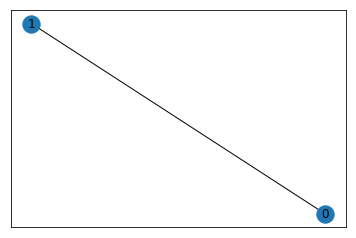

In [ ]:
TextRankSummarizer(clean_texts[45],clean_summaries[45])

In [ ]:
LexRankSummarizerSumy(clean_texts[45],clean_summaries[45])

Original Text: this seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and does not have quite as much flavor either. it did not pass muster with my kids, so i probably will not buy it again.

Human Summary: hearty oatmeal

LexRank Summarizer: this seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and does not have quite as much flavor either.



In [ ]:
LuhnSummarizer(clean_texts[45],clean_summaries[45])

Original Text: this seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and does not have quite as much flavor either. it did not pass muster with my kids, so i probably will not buy it again.

Human Summary: hearty oatmeal

Luhn Summarizer: this seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and does not have quite as much flavor either

